In [1]:
from copy               import copy
from matplotlib         import pyplot
from multiprocessing    import Pool
from numpy              import max, corrcoef
from os                 import listdir
from pandas             import read_csv
from subprocess         import run

from file_services.fasta_file_service import FastaFileService
from file_services.fastq_file_service import FastqFileService
from file_services.paf_file_service   import PafFileService
from file_services.utils              import get_read_reader

class SequenceMappingQueue():
    """
    A queue for the parallel reading of sequences and their corresponding mappings from
    .paf-files generated by minimap2 in single-threaded mode.

    Idea:
    The Queue holds a single query and a list of n mappings, the first n-1 of them
    corresponding to the query pair.

    Using queue() yields the query and all it's corresponding mappings and removes
    them from the queue. The previous state of the queue is then restored by first loading
    the next query. If it does not correspond to the query, the state of the queue is
    already restored. If not, more mappings are loaded until we find one that does not
    correspond to the query pair.
    """

    def get_query_id(cls, query):

        return query["header"][1:].split(" ")[0]

    def __init__(self, query, paf):

        self.queries = get_read_reader(query).read(query)
        self.paf     = PafFileService().read(paf)

        self.current_query    = None
        self.current_mappings = [next(self.paf)]

        self.restore_state()
                
    def print_current_state(self):

        print("Current query:")
        print(self.get_query_id(self.current_query))
        print("Current mappings:")
        for m in self.current_mappings:
            print("Query: "+m["query_name"]+" Reference: "+m["target_name"])
            print(m)
        print()

    def restore_state(self):
    
        self.current_query = next(self.queries)
        
        query_id = self.get_query_id(self.current_query)

        while query_id in self.current_mappings[len(self.current_mappings)-1]["query_name"]:
            self.current_mappings.append(next(self.paf))

    def queue(self):
        
        while True:

            yield self.current_query, self.current_mappings[:-1]

            try:  
                self.current_query      = None
                self.current_mappings   = [self.current_mappings[-1]]
                self.restore_state()
            except:
                break

def filter_reads(arg):

    reads_in  = arg[0]
    reads_out = "chr1_"+arg[0]
    paf       = arg[1]
    thread    = arg[2]

    filtered_reads = []
    writer         = FastqFileService()

    process = 0
    filter  = 0

    for read, mappings in SequenceMappingQueue(reads_in, paf).queue():
        process += 1
        if any([m for m in mappings if int(m["alignment_quality"])>=0]):
            filtered_reads.append(read)
            filter += 1
            if len(filtered_reads) > 25:
                writer.write(reads_out, filtered_reads, mode="a")
                filtered_reads = []
        if process % 2_000_000 == 0:
            r = round(100*filter/process,5)
            p = int(process / 1_000_000)
            print("Thread {0}: {1:>3}m processed ({2} % filtered)".format(thread, p, r))

# Creating a benchmark dataset with mouse chromosome 1 reads

Creation of a dataset with RNA short and long reads from multiple tissues for the evaluation of hybrid long read correction methods for transcriptome assemblies is performed.<br>
**Short reads:**<br>
From (brain, heart, kidney, liver, lung, and stomach) of the mouse (strain C57BL/6JJcl) were downloaded from the "Comprehensive Mouse Transcriptomic BodyMap across 17 Tissues by RNA-seq" (https://www.ncbi.nlm.nih.gov/bioproject?LinkName=biosample_bioproject&from_uid=6344316)<br>
**Long reads:**<br>
Simulated accordingly with NanoSim (https://github.com/bcgsc/NanoSim)

**Required tools:**

- seqtk (https://github.com/lh3/seqtk)
- minimap2 (https://github.com/lh3/minimap2)
- kallisto (https://github.com/pachterlab/kallisto)

All tools can easily be installed with conda

**Multi-threading:**

Seven threads are used (can be adapted in Section 2)

## 1. Chromosome 1 transcripts

We first need to filter the chromosome 1 transcripts

### 1.1 Retrieving transcript IDs from the GFF-file

In [2]:
gff  = read_csv("./genomic.gff", sep="\t", header=None)
gff  = gff.loc[gff[2].str.contains("RNA", na=False) & (gff[0]=="NC_000067.7")]
IDs  = [s.split(";")[0][7:] for s in list(gff[8]) if s.startswith("ID=rna")]

display(gff)

,0,1,2,3,4,5,6,7,8
2,NC_000067.7,cmsearch,snRNA,3172239.0,3172348.0,.,+,.,ID=rna-XR_004936710.1;Parent=gene-Gm26206;Dbxr...
5,NC_000067.7,Gnomon,mRNA,3269956.0,3741733.0,.,-,.,ID=rna-XM_006495550.5;Parent=gene-Xkr4;Dbxref=...
13,NC_000067.7,BestRefSeq,mRNA,3284705.0,3741721.0,.,-,.,ID=rna-NM_001011874.1;Parent=gene-Xkr4;Dbxref=...
20,NC_000067.7,Gnomon,mRNA,3393039.0,3741733.0,.,-,.,ID=rna-XM_011238395.4;Parent=gene-Xkr4;Dbxref=...
27,NC_000067.7,Gnomon,mRNA,3420932.0,3741733.0,.,-,.,ID=rna-XM_036152287.1;Parent=gene-Xkr4;Dbxref=...
...,...,...,...,...,...,...,...,...,...
210409,NC_000067.7,Gnomon,mRNA,194819555.0,194859096.0,.,-,.,ID=rna-XM_006497225.4;Parent=gene-Cr2;Dbxref=G...
210447,NC_000067.7,Gnomon,mRNA,194819555.0,194858956.0,.,-,.,ID=rna-XM_006497224.4;Parent=gene-Cr2;Dbxref=G...
210491,NC_000067.7,Gnomon,mRNA,194819555.0,194858918.0,.,-,.,ID=rna-XM_006497222.4;Parent=gene-Cr2;Dbxref=G...
210543,NC_000067.7,Gnomon,mRNA,194819555.0,194850725.0,.,-,.,ID=rna-XM_017314050.3;Parent=gene-Cr2;Dbxref=G...


### 1.2 Creating a FASTA-file with chromosome 1 transcripts

In [3]:
transcripts      = list(FastaFileService().read("rna.fna"))
transcripts_chr1 = []

IDs_copy = copy(IDs)

for t in transcripts:
    if t["header"].split(" ")[0][1:] in IDs_copy:
        transcripts_chr1.append(t)
        IDs_copy.remove(t["header"].split(" ")[0][1:])

print(len(list(transcripts)))
print(len(transcripts_chr1))

FastaFileService().write("rna_chr1.fna", transcripts_chr1)

134700
7717


## 2. Filtering short reads

Short reads will be filtered by mapping them to the filtered transcrips using minimap2.<br>
Minimap2 must run on a single thread so mappings are output in the order of the reads<br>
To still be able to use multiple threads we will first split the reads using Seqtk<br>

(Takes ~15min)

In [4]:
threads = 7

# File splitting
run(["seqtk","split","-n",str(threads),"illumina_1_split","illumina_1.fastq"], check=True)
run(["seqtk","split","-n",str(threads),"illumina_2_split","illumina_2.fastq"], check=True)

# Minimap2 index creation
run(["minimap2","-x","sr","-t",str(threads),"-d","rna_chr1.mm2","rna_chr1.fna"], check=True)

# Minimap2 mapping
files_left   = sorted([f for f in listdir() if "illumina_1_split" in f])
files_right  = sorted([f for f in listdir() if "illumina_2_split" in f])
files_paired = zip(files_left, files_right)
def mm2_map(arg):
    run(["minimap2","-x","sr","-t",str(1),"-o",f"illumina_split_{arg[0]+1}.paf","rna_chr1.mm2",arg[1][0],arg[1][1]], check=True)
with Pool(processes=threads) as pool:
    pool.map(mm2_map, list(enumerate(files_paired)))

# Read filtering
files_mappings = sorted([f for f in listdir() if ".paf" in f])
with Pool(processes=threads) as pool:
    pool.map(filter_reads, zip(files_left,  files_mappings, list(range(threads))))
    pool.map(filter_reads, zip(files_right, files_mappings, list(range(threads))))

[M::mm_idx_gen::1.328*0.97] collected minimizers
[M::mm_idx_gen::1.443*1.42] sorted minimizers
[M::main::1.675*1.36] loaded/built the index for 7717 target sequence(s)
[M::mm_idx_stat] kmer size: 21; skip: 11; is_hpc: 0; #seq: 7717
[M::mm_idx_stat::1.699*1.35] distinct minimizers: 1360613 (42.12% are singletons); average occurrences: 4.248; average spacing: 6.007; total length: 34718461
[M::main] Version: 2.28-r1209
[M::main] CMD: minimap2 -x sr -t 7 -d rna_chr1.mm2 rna_chr1.fna
[M::main] Real time: 1.727 sec; CPU: 2.324 sec; Peak RSS: 0.696 GB
[M::main::0.181*1.00] loaded/built the index for 7717 target sequence(s)
[M::mm_mapopt_update::0.181*1.00] mid_occ = 1000
[M::mm_idx_stat] kmer size: 21; skip: 11; is_hpc: 0; #seq: 7717
[M::main::0.197*1.00] loaded/built the index for 7717 target sequence(s)
[M::main::0.197*1.00] loaded/built the index for 7717 target sequence(s)
[M::mm_mapopt_update::0.197*1.00] mid_occ = 1000
[M::mm_idx_stat] kmer size: 21; skip: 11; is_hpc: 0; #seq: 7717
[M::

Thread 4:   2m processed (7.3469 % filtered)
Thread 0:   2m processed (7.34625 % filtered)
Thread 3:   2m processed (7.3465 % filtered)
Thread 1:   2m processed (7.34655 % filtered)
Thread 5:   2m processed (7.34535 % filtered)
Thread 2:   2m processed (7.35325 % filtered)
Thread 6:   2m processed (7.352 % filtered)
Thread 4:   4m processed (6.86348 % filtered)
Thread 0:   4m processed (6.86282 % filtered)
Thread 6:   4m processed (6.86587 % filtered)
Thread 2:   4m processed (6.86268 % filtered)
Thread 5:   4m processed (6.8641 % filtered)
Thread 3:   4m processed (6.8606 % filtered)
Thread 1:   4m processed (6.86447 % filtered)
Thread 4:   6m processed (6.42258 % filtered)
Thread 5:   6m processed (6.42298 % filtered)
Thread 0:   6m processed (6.42242 % filtered)
Thread 3:   6m processed (6.41808 % filtered)
Thread 6:   6m processed (6.42402 % filtered)
Thread 2:   6m processed (6.4202 % filtered)
Thread 1:   6m processed (6.42243 % filtered)
Thread 0:   8m processed (6.48821 % filte

In [5]:
# Finish (Merge files)
files_left_chr1  = sorted([f for f in listdir() if "chr1_illumina_1_split" in f])
files_right_chr1 = sorted([f for f in listdir() if "chr1_illumina_2_split" in f])
for i, f in enumerate(files_left_chr1):
    print(f"Left: merge {i+1}")
    FastqFileService.write("chr1_illumina_1.fastq", FastqFileService.read(f), mode="a")
for i, f in enumerate(files_right_chr1):
    print(f"Right: merge {i+1}")
    FastqFileService.write("chr1_illumina_2.fastq", FastqFileService.read(f), mode="a")

# Finish (Cleanup)
for file in files_left + files_right + files_mappings + files_left_chr1 + files_right_chr1 :
    run(["rm", file])

Left: merge 1
Left: merge 2
Left: merge 3
Left: merge 4
Left: merge 5
Left: merge 6
Left: merge 7
Right: merge 1
Right: merge 2
Right: merge 3
Right: merge 4
Right: merge 5
Right: merge 6
Right: merge 7


## 3. Abundance estimation with Kallisto

For the simulation of long reads with NanoSim, an expression profile is needed, which can be generated with Kallisto.<br>
It also provides an oppurtunity to check if the quality of the read filtering process.

(Takes ~10min)

In [6]:
# Index construction
run(["kallisto","index","-t",str(threads),"-i","rna.idx","rna.fna"], check=True)

# Quantification
run(["kallisto","quant","-t",str(threads),"-i","rna.idx","-o","kallisto_all",  "illumina_1.fastq",      "illumina_2.fastq"],      check=True)
run(["kallisto","quant","-t",str(threads),"-i","rna.idx","-o","kallisto_chr1", "chr1_illumina_1.fastq", "chr1_illumina_2.fastq"], check=True)


[build] loading fasta file rna.fna
[build] k-mer length: 31
[build] warning: clipped off poly-A tail (longer than 10)
        from 10211 target sequences
[build] warning: replaced 30 non-ACGUT characters in the input sequence
        with pseudorandom nucleotides


KmerStream::KmerStream(): Start computing k-mer cardinality estimations (1/2)
KmerStream::KmerStream(): Start computing k-mer cardinality estimations (1/2)
KmerStream::KmerStream(): Finished
CompactedDBG::build(): Estimated number of k-mers occurring at least once: 123737229
CompactedDBG::build(): Estimated number of minimizer occurring at least once: 30662041
CompactedDBG::filter(): Processed 516666991 k-mers in 134700 reads
CompactedDBG::filter(): Found 123932282 unique k-mers
CompactedDBG::filter(): Number of blocks in Bloom filter is 845861
CompactedDBG::construct(): Extract approximate unitigs (1/2)
CompactedDBG::construct(): Extract approximate unitigs (2/2)
CompactedDBG::construct(): Closed all input files

CompactedDBG::construct(): Splitting unitigs (1/2)

CompactedDBG::construct(): Splitting unitigs (2/2)
CompactedDBG::construct(): Before split: 622626 unitigs
CompactedDBG::construct(): After split (1/1): 622626 unitigs
CompactedDBG::construct(): Unitigs split: 1374
Compacted

[build] building MPHF
[build] creating equivalence classes ... 
[build] target de Bruijn graph has k-mer length 31 and minimizer length 23
[build] target de Bruijn graph has 555272 contigs and contains 124043958 k-mers 


[quant] fragment length distribution will be estimated from the data
[index] k-mer length: 31
[index] number of targets: 134,700
[index] number of k-mers: 124,043,958
[quant] running in paired-end mode
[quant] will process pair 1: illumina_1.fastq
                             illumina_2.fastq
[progress] 57M reads processed (82.3% mapped)              done
[quant] processed 58,219,222 reads, 47,944,642 reads pseudoaligned
[quant] estimated average fragment length: 157.7
[   em] quantifying the abundances ... done
[   em] the Expectation-Maximization algorithm ran for 1,412 rounds


[quant] fragment length distribution will be estimated from the data
[index] k-mer length: 31
[index] number of targets: 134,700
[index] number of k-mers: 124,043,958
[quant] running in pair

CompletedProcess(args=['kallisto', 'quant', '-t', '7', '-i', 'rna.idx', '-o', 'kallisto_chr1', 'chr1_illumina_1.fastq', 'chr1_illumina_2.fastq'], returncode=0)

### Checking the sucess of the read filtering process and long read simulation

Read counts of the selected transcripts remain largely untouched, while read counts for non-selected genes are redouced.<br>
Overall ~93% of read pairs were discarded.<br>
Read counts and tpm for non-selected genes should however be set to 0 to prevent simulation of non-selected transcripts.

7717
7717


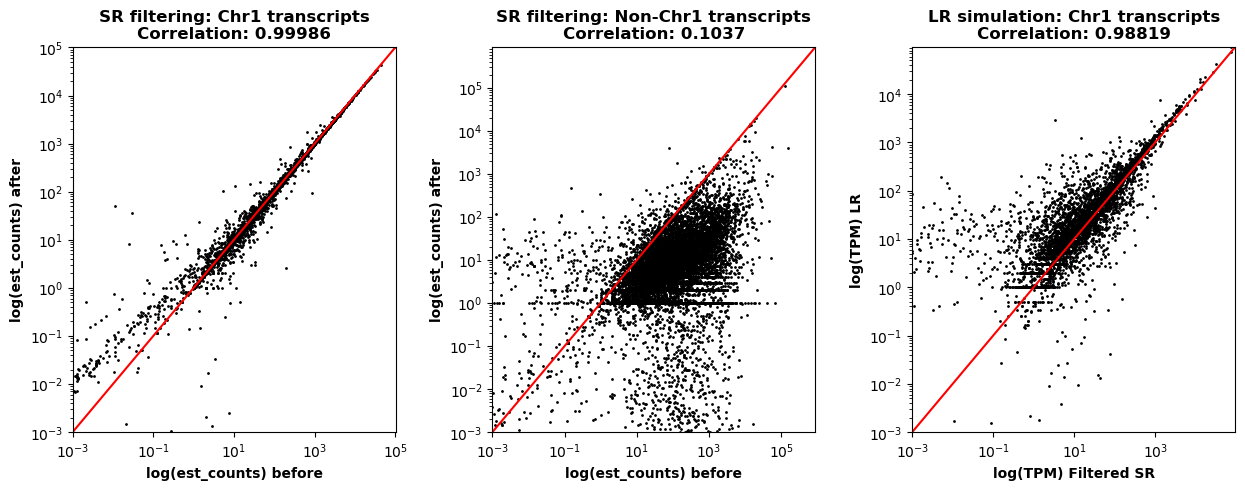

In [7]:
sr_abundance_unfiltered        = read_csv("kallisto_all/abundance.tsv", sep="\t")
sr_abundance_filtered          = read_csv("kallisto_chr1/abundance.tsv", sep="\t")
lr_abundance                   = read_csv("abundance_longreads.tsv", sep="\t")
lr_abundance_chr1              = lr_abundance.loc[lr_abundance["ID"].isin([id.replace("_","",) for id in IDs])]
sr_abundance_unfiltered_chr1   = sr_abundance_unfiltered.loc[sr_abundance_unfiltered["target_id"].isin(IDs)]
sr_abundance_filtered_chr1     = sr_abundance_filtered.loc[sr_abundance_unfiltered["target_id"].isin(IDs)]
sr_abundance_unfiltered_nchr1  = sr_abundance_unfiltered.loc[~sr_abundance_unfiltered["target_id"].isin(IDs)]
sr_abundance_filtered_nchr1    = sr_abundance_filtered.loc[~sr_abundance_unfiltered["target_id"].isin(IDs)]

def abundance_change_plot(b, a, ax):

    max_abundance = max([int(max(b)),int(max(a))])

    ax.set_xlim(xmin=0.001,xmax=max_abundance)
    ax.set_ylim(ymin=0.001,ymax=max_abundance)

    ax.scatter(b,a, s=1,color="black")
    ax.plot([0,max_abundance],[0,max_abundance], color="red")


fig, axes = pyplot.subplots(1,3, figsize=(15,5))
show      = 'est_counts'


# Expression profile conservation for chr1 transcripts (Before and after Filtering)
before = sr_abundance_unfiltered_chr1[show]
after  = sr_abundance_filtered_chr1[show]
correl = round(corrcoef(before,after)[0,1],5)
axes[0].set_title(f"SR filtering: Chr1 transcripts\nCorrelation: {correl}", fontweight="bold")
abundance_change_plot(before, after, axes[0])

# Expression profile conservation for non-chr1 transcripts (Before and after Filtering)
before = sr_abundance_unfiltered_nchr1[show]
after  = sr_abundance_filtered_nchr1[show]
correl = round(corrcoef(before,after)[0,1],5)
axes[1].set_title(f"SR filtering: Non-Chr1 transcripts\nCorrelation: {correl}", fontweight="bold")
abundance_change_plot(before, after, axes[1])

# Expression profile conservation for chr1 transcripts (SR and LR)
before = sr_abundance_filtered_chr1["tpm"]
after  = lr_abundance_chr1["TPM"]
print(len(before))
print(len(after))
correl = round(corrcoef(before,after)[0,1],5)
axes[2].set_title(f"LR simulation: Chr1 transcripts\nCorrelation: {correl}", fontweight="bold")
abundance_change_plot(before, after, axes[2])

for i in range(3):
    if i<2:
        axes[i].set_xlabel(f"log({show}) before", fontweight="bold")
        axes[i].set_ylabel(f"log({show}) after",  fontweight="bold")
    else:
        axes[i].set_xlabel(f"log(TPM) Filtered SR", fontweight="bold")
        axes[i].set_ylabel(f"log(TPM) LR",  fontweight="bold")
    axes[i].set_xscale("log")
    axes[i].set_yscale("log")

pyplot.subplots_adjust(wspace=0.3)